# DATA 622 Homework 7: Neural Networks Training

This notebook trains the CIFAR100 neural-network models for Homework 7 using a Google Colab GPU runtime. The final written report is prepared separately in the Quarto `.qmd` file and PDF.

Run the cells from top to bottom. The full training script is embedded in this notebook and written to `hw7_training_workflow.py` inside the Colab session, so no separate script upload is required. The verification cell near the end checks that all CSV and plot files needed by the final report were created before downloading `hw7_results.zip`.


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("GPU is not available. In Colab, use Runtime > Change runtime type > GPU.")


CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p figures
!ls -lh


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
total 36K
drwxr-xr-x 3 root root 4.0K May  1 14:57 data
drwx------ 5 root root 4.0K May  1 14:55 drive
drwxr-xr-x 2 root root 4.0K May  1 15:48 figures
-rw-r--r-- 1 root root 5.7K May  1 15:48 hw7_results.zip
-rw-r--r-- 1 root root 8.4K May  1 14:54 hw7_training_workflow.py
drwxr-xr-x 1 root root 4.0K Apr 16 13:33 sample_data


In [ ]:
%%writefile hw7_training_workflow.py
import copy
import os
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


SEED = 622
DATA_DIR = "data"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = DEVICE == "cuda"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

mean = (0.5071, 0.4865, 0.4409)
std = (0.2673, 0.2564, 0.2762)

plain_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.03),
    transforms.RandomRotation(degrees=8),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.12), ratio=(0.3, 3.3)),
])


class CIFARCNN(nn.Module):
    def __init__(
        self,
        sizes=(32, 64, 128, 256),
        convs_per_block=1,
        use_batchnorm=False,
        dropout=0.5,
    ):
        super().__init__()
        layers = []
        in_channels = 3

        for out_channels in sizes:
            for _ in range(convs_per_block):
                layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
                if use_batchnorm:
                    layers.append(nn.BatchNorm2d(out_channels))
                layers.append(nn.ReLU(inplace=True))
                in_channels = out_channels
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        self.features = nn.Sequential(*layers)
        final_side = 32 // (2 ** len(sizes))
        final_width = sizes[-1] * final_side * final_side

        classifier_layers = [
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(final_width, 512),
        ]
        if use_batchnorm:
            classifier_layers.append(nn.BatchNorm1d(512))
        classifier_layers += [
            nn.ReLU(inplace=True),
            nn.Linear(512, 100),
        ]
        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x):
        return self.classifier(self.features(x))


@torch.no_grad()
def evaluate(model, loader, loss_fn, device=DEVICE):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    all_y = []
    all_pred = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        pred = logits.argmax(dim=1)

        total_loss += loss.item() * len(y)
        total_correct += (pred == y).sum().item()
        total_n += len(y)
        all_y.append(y.cpu())
        all_pred.append(pred.cpu())

    return {
        "loss": total_loss / total_n,
        "accuracy": total_correct / total_n,
        "y_true": torch.cat(all_y).numpy(),
        "y_pred": torch.cat(all_pred).numpy(),
    }


def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    weight_decay,
    optimizer_name="RMSprop",
    device=DEVICE,
    patience=6,
):
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()

    if optimizer_name.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    best_state = None
    best_val_acc = -np.inf
    best_epoch = None
    epochs_without_improvement = 0
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_n = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(x)
                loss = loss_fn(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * len(y)
            train_correct += (logits.argmax(dim=1) == y).sum().item()
            train_n += len(y)

        val_metrics = evaluate(model, val_loader, loss_fn, device)
        row = {
            "epoch": epoch,
            "train_loss": train_loss / train_n,
            "train_accuracy": train_correct / train_n,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
        }
        history.append(row)

        if row["val_accuracy"] > best_val_acc:
            best_val_acc = row["val_accuracy"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(f"{epoch:03d}: train={row['train_accuracy']:.4f}, val={row['val_accuracy']:.4f}")

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_epoch


def safe_name(name):
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")


def class_accuracy_table(y_true, y_pred, class_names):
    rows = []
    for idx, class_name in enumerate(class_names):
        mask = y_true == idx
        rows.append({
            "class": class_name,
            "n_validation": int(mask.sum()),
            "accuracy": float((y_pred[mask] == y_true[mask]).mean()),
        })
    return pd.DataFrame(rows).sort_values("accuracy", ascending=False)


def save_class_accuracy_diagnostics(val_metrics, class_names):
    class_acc = class_accuracy_table(
        val_metrics["y_true"],
        val_metrics["y_pred"],
        class_names,
    )
    class_acc.to_csv("figures/baseline_class_accuracy.csv", index=False)

    top10 = class_acc.head(10)
    bottom10 = class_acc.tail(10).sort_values("accuracy")
    pd.concat([top10.assign(group="highest"), bottom10.assign(group="lowest")]).to_csv(
        "figures/baseline_class_accuracy_top_bottom.csv",
        index=False,
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
    axes[0].barh(top10["class"], top10["accuracy"], color="#4C78A8")
    axes[0].invert_yaxis()
    axes[0].set_title("10 Highest Validation Accuracies")
    axes[0].set_xlabel("Accuracy")

    axes[1].barh(bottom10["class"], bottom10["accuracy"], color="#E45756")
    axes[1].set_title("10 Lowest Validation Accuracies")
    axes[1].set_xlabel("Accuracy")

    fig.suptitle("Baseline CNN Class-Level Validation Accuracy", y=1.03)
    fig.tight_layout()
    fig.savefig("figures/baseline_class_accuracy_top_bottom.png", dpi=180, bbox_inches="tight")
    plt.close(fig)


def unnormalize(img, mean=mean, std=std):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(img.cpu() * std_t + mean_t, 0, 1)


@torch.no_grad()
def save_misclassified_examples(model, dataset, class_names, device=DEVICE, n=5):
    model.eval()
    errors = []
    for idx in range(len(dataset)):
        x, y = dataset[idx]
        logits = model(x.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).item()
        if pred != y:
            errors.append((x, y, pred))
        if len(errors) == n:
            break

    rows = [
        {"true_class": class_names[y], "predicted_class": class_names[pred]}
        for _, y, pred in errors
    ]
    pd.DataFrame(rows).to_csv("figures/baseline_misclassified_examples.csv", index=False)

    fig, axes = plt.subplots(1, len(errors), figsize=(2.5 * len(errors), 3.0))
    if len(errors) == 1:
        axes = [axes]

    for ax, (x, y, pred) in zip(axes, errors):
        ax.imshow(unnormalize(x).permute(1, 2, 0))
        ax.set_title(f"True: {class_names[y]}\nPred: {class_names[pred]}", fontsize=8)
        ax.axis("off")

    fig.suptitle("Baseline CNN Misclassified Validation Images", y=1.02)
    fig.tight_layout()
    fig.savefig("figures/baseline_misclassified_examples.png", dpi=180, bbox_inches="tight")
    plt.close(fig)


def main():
    os.makedirs("figures", exist_ok=True)
    print(f"Using device: {DEVICE}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")

    full_plain = datasets.CIFAR100(DATA_DIR, train=True, download=True, transform=plain_transform)
    full_augmented = datasets.CIFAR100(DATA_DIR, train=True, download=True, transform=augmented_transform)
    test_set = datasets.CIFAR100(DATA_DIR, train=False, download=True, transform=plain_transform)

    train_n = int(0.8 * len(full_plain))
    val_n = len(full_plain) - train_n
    split_generator = torch.Generator().manual_seed(SEED)
    train_plain, val_set = random_split(full_plain, [train_n, val_n], generator=split_generator)
    train_augmented = torch.utils.data.Subset(full_augmented, train_plain.indices)

    batch_size = 512 if DEVICE == "cuda" else 128
    num_workers = 2 if DEVICE == "cuda" else 0
    pin_memory = DEVICE == "cuda"
    train_plain_loader = DataLoader(train_plain, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
    train_aug_loader = DataLoader(train_augmented, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

    loss_fn = nn.CrossEntropyLoss()
    baseline_epochs = int(os.environ.get("HW7_BASELINE_EPOCHS", "50"))
    model_specs = [
        ("Baseline CNN", CIFARCNN((32, 64, 128, 256), 1, False, 0.50), train_plain_loader, baseline_epochs, 0.001, 0.0, "RMSprop"),
        ("Augmented CNN", CIFARCNN((32, 64, 128, 256), 1, False, 0.50), train_aug_loader, 40, 0.001, 1e-4, "RMSprop"),
        ("Wider augmented CNN", CIFARCNN((64, 128, 256, 512), 1, False, 0.55), train_aug_loader, 40, 0.0005, 5e-4, "Adam"),
        ("Deeper CNN without batch norm", CIFARCNN((64, 128, 256, 512), 3, False, 0.60), train_aug_loader, 25, 0.0003, 5e-4, "Adam"),
        ("Deeper CNN with batch norm", CIFARCNN((64, 128, 256, 512), 3, True, 0.50), train_aug_loader, 40, 0.001, 1e-4, "Adam"),
    ]
    diagnostics_only = os.environ.get("HW7_MODE") == "baseline_diagnostics"
    if diagnostics_only:
        model_specs = model_specs[:1]

    rows = []
    for name, model, loader, epochs, lr, weight_decay, optimizer_name in model_specs:
        print(f"\n=== Training {name} for up to {epochs} epochs ===")
        model, history, best_epoch = train_model(
            model,
            loader,
            val_loader,
            epochs,
            lr,
            weight_decay,
            optimizer_name,
            patience=6,
        )
        history.to_csv(f"figures/{safe_name(name)}_history.csv", index=False)
        val_metrics = evaluate(model, val_loader, loss_fn)
        test_metrics = evaluate(model, test_loader, loss_fn)
        if name == "Baseline CNN":
            torch.save(model.state_dict(), "figures/baseline_cnn_state_dict.pt")
            save_class_accuracy_diagnostics(val_metrics, full_plain.classes)
            save_misclassified_examples(model, val_set, full_plain.classes)
        rows.append({
            "model": name,
            "best_epoch": best_epoch,
            "validation_accuracy": val_metrics["accuracy"],
            "test_accuracy": test_metrics["accuracy"],
            "test_error": 1 - test_metrics["accuracy"],
        })
        partial_name = "baseline_diagnostics_results_partial.csv" if diagnostics_only else "final_model_results_partial.csv"
        pd.DataFrame(rows).to_csv(f"figures/{partial_name}", index=False)

    results_name = "baseline_diagnostics_results.csv" if diagnostics_only else "final_model_results.csv"
    pd.DataFrame(rows).to_csv(f"figures/{results_name}", index=False)


if __name__ == "__main__":
    main()


Overwriting hw7_training_workflow.py


In [ ]:
!pip install -q torch torchvision pandas matplotlib


In [ ]:
# Full training run. This creates histories, final results, and Problem 1 diagnostic plots.
!mkdir -p figures
!python hw7_training_workflow.py


Using device: cuda
GPU: NVIDIA A100-SXM4-40GB

=== Training Baseline CNN for up to 50 epochs ===
001: train=0.0415, val=0.0583
002: train=0.0957, val=0.0789
003: train=0.1336, val=0.1189
004: train=0.1679, val=0.1394
005: train=0.1970, val=0.1423
006: train=0.2269, val=0.1997
007: train=0.2562, val=0.2328
008: train=0.2752, val=0.2475
009: train=0.3014, val=0.2430
010: train=0.3190, val=0.1970
011: train=0.3397, val=0.2811
012: train=0.3598, val=0.3176
013: train=0.3835, val=0.2759
014: train=0.3942, val=0.3369
015: train=0.4194, val=0.3384
016: train=0.4334, val=0.3490
017: train=0.4504, val=0.3260
018: train=0.4649, val=0.3512
019: train=0.4787, val=0.2959
020: train=0.4915, val=0.3219
021: train=0.5084, val=0.3769
022: train=0.5289, val=0.3707
023: train=0.5342, val=0.3913
024: train=0.5526, val=0.3964
025: train=0.5662, val=0.3815
026: train=0.5780, val=0.4033
027: train=0.5874, val=0.3933
028: train=0.6009, val=0.3786
029: train=0.6117, val=0.3636
030: train=0.6217, val=0.3768
031

In [ ]:
# Verify that the run produced every file needed by the Quarto report.
from pathlib import Path
import pandas as pd

expected_files = [
    "figures/baseline_cnn_history.csv",
    "figures/augmented_cnn_history.csv",
    "figures/wider_augmented_cnn_history.csv",
    "figures/deeper_cnn_without_batch_norm_history.csv",
    "figures/deeper_cnn_with_batch_norm_history.csv",
    "figures/final_model_results.csv",
    "figures/baseline_class_accuracy.csv",
    "figures/baseline_class_accuracy_top_bottom.csv",
    "figures/baseline_class_accuracy_top_bottom.png",
    "figures/baseline_misclassified_examples.csv",
    "figures/baseline_misclassified_examples.png",
    "figures/baseline_cnn_state_dict.pt",
]

missing = [f for f in expected_files if not Path(f).exists()]
if missing:
    raise FileNotFoundError("Missing required output files:\n" + "\n".join(missing))

results = pd.read_csv("figures/final_model_results.csv")
print("All expected files were created.")
print("\nFinal model results:")
display(results)

print("\nProblem 1 class accuracy preview:")
display(pd.read_csv("figures/baseline_class_accuracy_top_bottom.csv").head(20))


All expected files were created.

Final model results:


,model,best_epoch,validation_accuracy,test_accuracy,test_error
0,Baseline CNN,46,0.4236,0.4316,0.5684
1,Augmented CNN,38,0.3750,0.3730,0.6270
2,Wider augmented CNN,40,0.4946,0.5025,0.4975
3,Deeper CNN without batch norm,1,0.0088,0.0100,0.9900
4,Deeper CNN with batch norm,34,0.6185,0.6177,0.3823



Problem 1 class accuracy preview:


,class,n_validation,accuracy,group
0,chair,101,0.821782,highest
1,road,104,0.807692,highest
2,sunflower,106,0.773585,highest
3,cockroach,99,0.767677,highest
4,plain,107,0.757009,highest
5,wardrobe,100,0.740000,highest
6,lawn_mower,91,0.736264,highest
7,maple_tree,101,0.732673,highest
8,skunk,97,0.731959,highest
9,cloud,104,0.730769,highest


Problem 1(b): class-level validation accuracy


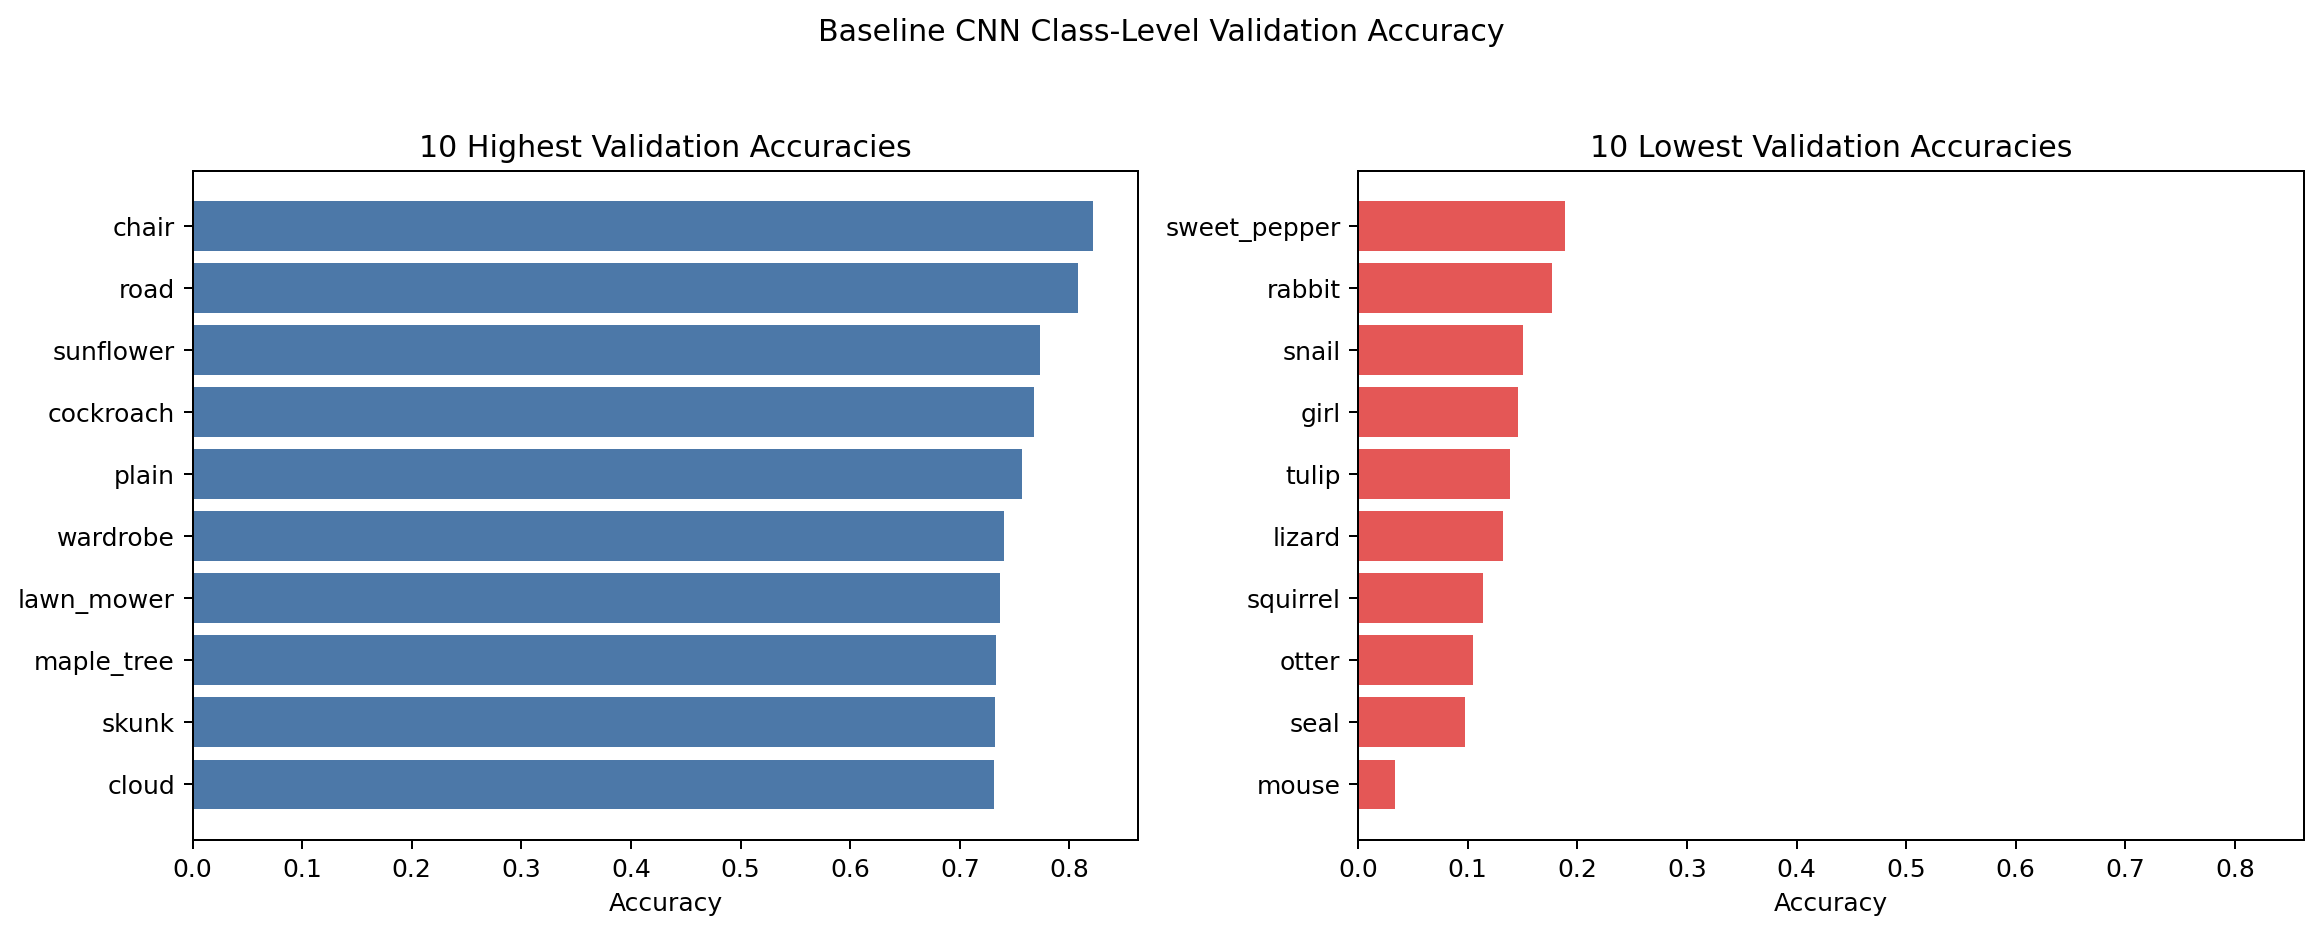

Problem 1(c): misclassified validation examples


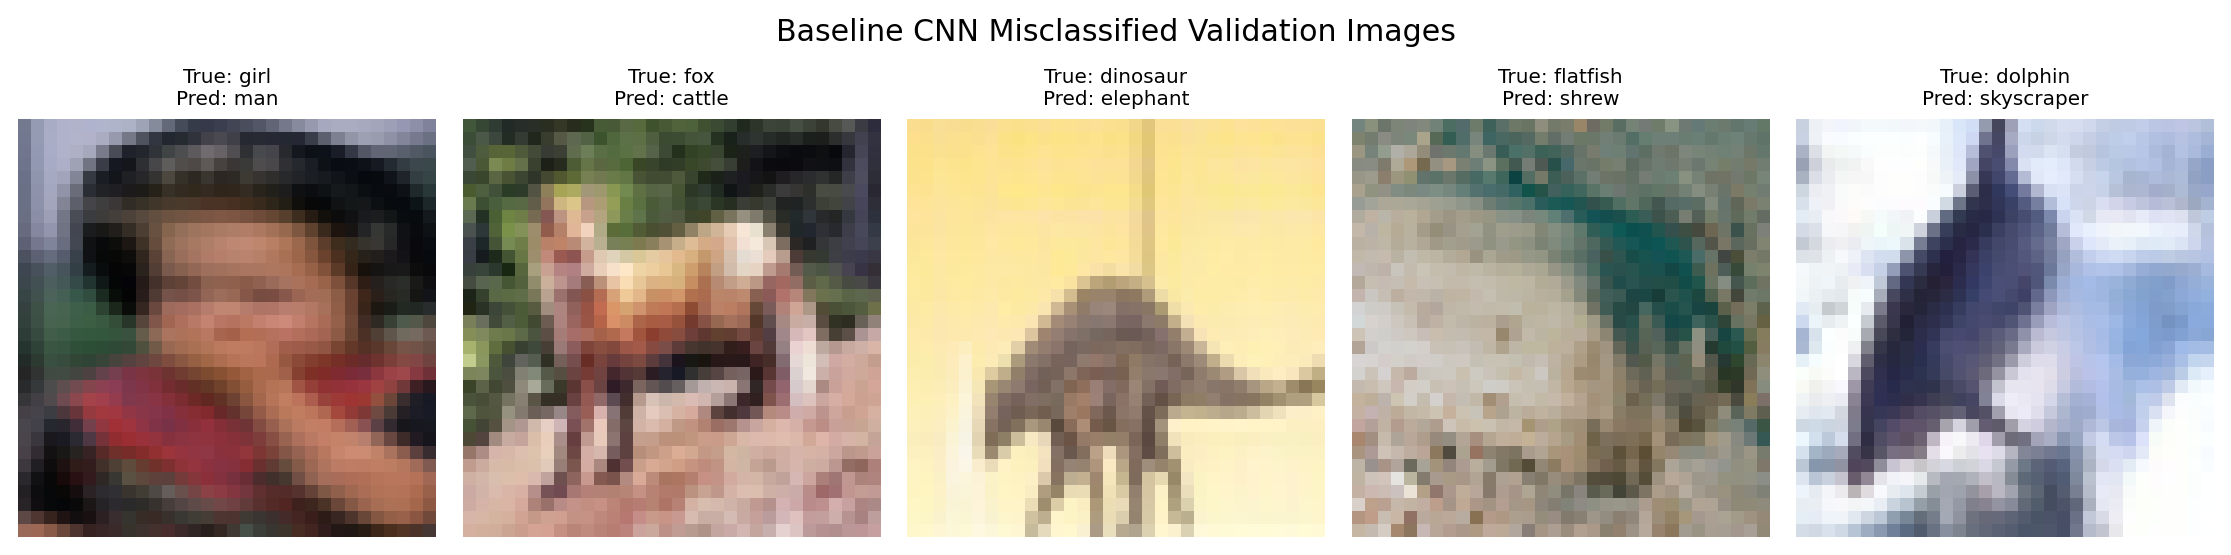

In [ ]:
from IPython.display import Image, display

print("Problem 1(b): class-level validation accuracy")
display(Image("figures/baseline_class_accuracy_top_bottom.png"))

print("Problem 1(c): misclassified validation examples")
display(Image("figures/baseline_misclassified_examples.png"))


In [ ]:
from google.colab import files
import shutil
from pathlib import Path

zip_path = shutil.make_archive("hw7_results", "zip", "figures")
backup_path = "/content/drive/MyDrive/hw7_results.zip"
shutil.copy(zip_path, backup_path)

print("Created:", zip_path)
print("Backed up to:", backup_path)
files.download("hw7_results.zip")


Created: /content/hw7_results.zip
Backed up to: /content/drive/MyDrive/hw7_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>